
# Part 1: Linear Regression
## Medical Insurance Cost Prediction - Linear Regression Analysis

### ST10500865
### Kamogelo Motau
#### 24 March 2026

**Objective:** Develop a linear regression model to predict medical insurance charges based on customer demographics and lifestyle factors for a South African medical aid scheme.

**Dataset:** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 1. Dataset Evaluation for Linear Regression Suitability

### Dataset Overview
The dataset contains medical insurance information with the following features:
- **age**: Age of primary beneficiary (integer)
- **sex**: Gender of beneficiary (categorical: male/female)
- **bmi**: Body mass index (continuous)
- **children**: Number of children covered (integer)
- **smoker**: Smoking status (categorical: yes/no)
- **region**: Geographic region (categorical: northeast/southeast/southwest/northwest)
- **charges**: Individual medical costs billed (continuous - target variable)

### Suitability Assessment for Linear Regression:

- **Target Variable:** `charges` is continuous - appropriate for regression

- **Feature Types:** Mix of numerical and categorical - can be encoded

- **Sample Size:** 1338 records - sufficient for reliable regression

- **Linearity Check Required:** Need to verify linear relationships

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Statistical libraries
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('insurance.csv')

# Display basic information
print("\nDATASET OVERVIEW\n")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


DATASET OVERVIEW

Dataset shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Data information and types
print("\nDATA TYPES AND INFO\n")
df.info()


DATA TYPES AND INFO

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# Check for missing values
print("\nMISSING VALUES CHECK\n")

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Values'] > 0])

if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset!")
else:
    print("\nMissing values detected - will need treatment")


MISSING VALUES CHECK

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

No missing values found in the dataset!


In [5]:
# Statistical summary of numerical features
print("\nSTATISTICAL SUMMARY - NUMERICAL FEATURES\n")

df.describe()


STATISTICAL SUMMARY - NUMERICAL FEATURES



,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 2. Analysis Plan

### a. Exploratory Data Analysis Plan:
1. **Univariate Analysis**: Examine distributions of individual variables
2. **Bivariate Analysis**: Explore relationships between features and target
3. **Outlier Detection**: Identify extreme values in numerical features
4. **Correlation Analysis**: Understand feature interdependencies

### b. Feature Selection Plan:
1. Encode categorical variables (sex, smoker, region)
2. Use statistical significance (p-values) for feature selection
3. Check multicollinearity using VIF
4. Consider interaction terms (smoker × bmi, age × bmi)

### c. Model Training Plan:
1. Split data: 80% training, 20% testing
2. Train multiple models: Simple Linear, Ridge, Lasso
3. Use 5-fold cross-validation
4. Hyperparameter tuning for regularization

### d. Evaluation Metrics Plan:
- **R-squared (R²)**: Model fit explanation
- **RMSE**: Prediction error in original units
- **MAE**: Average absolute prediction error
- **Residual Analysis**: Check model assumptions
- **Cross-validation Score**: Model stability

## 3. Exploratory Data Analysis (EDA)

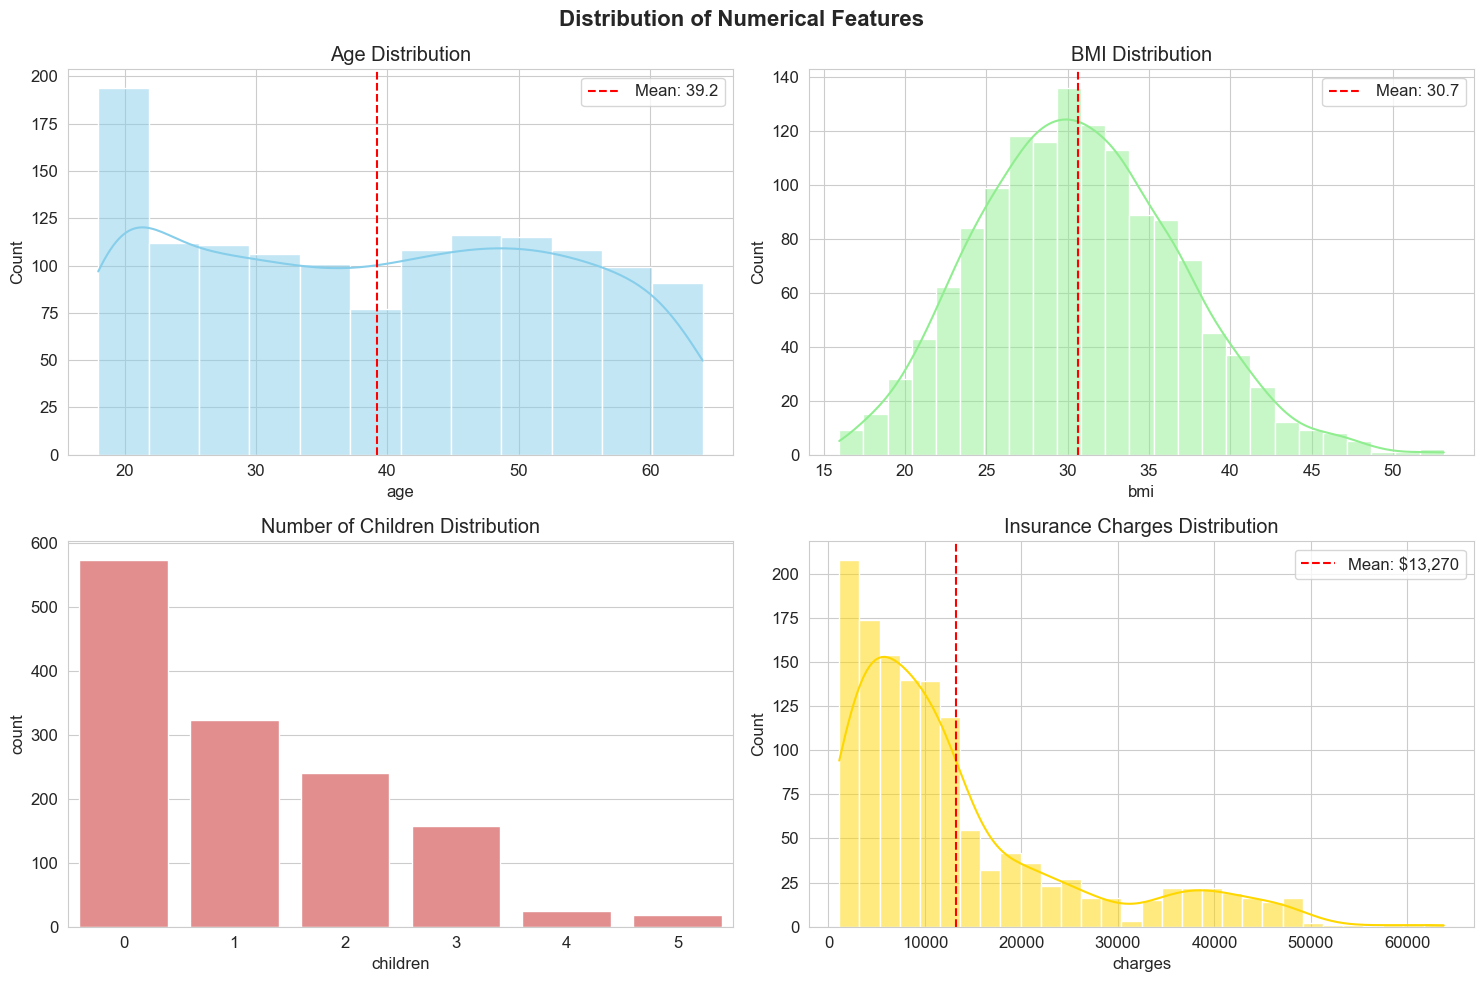

In [6]:
# 3.1 Univariate Analysis - Numerical Features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

# Age distribution
sns.histplot(df['age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
axes[0, 0].legend()

# BMI distribution
sns.histplot(df['bmi'], kde=True, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('BMI Distribution')
axes[0, 1].axvline(df['bmi'].mean(), color='red', linestyle='--', label=f'Mean: {df["bmi"].mean():.1f}')
axes[0, 1].legend()

# Children distribution
sns.countplot(x='children', data=df, ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Number of Children Distribution')

# Charges distribution
sns.histplot(df['charges'], kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Insurance Charges Distribution')
axes[1, 1].axvline(df['charges'].mean(), color='red', linestyle='--', label=f'Mean: ${df["charges"].mean():,.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

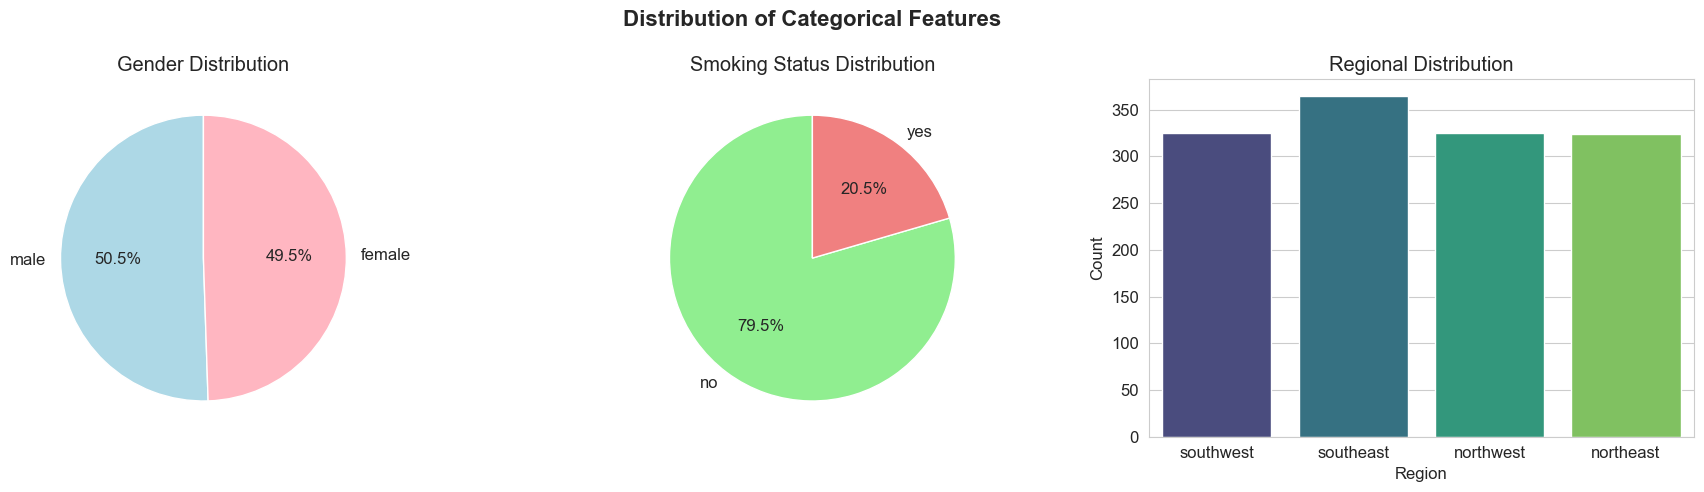

In [7]:
# 3.2 Univariate Analysis - Categorical Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold')

# Sex distribution
sex_counts = df['sex'].value_counts()
axes[0].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', 
            colors=['lightblue', 'lightpink'], startangle=90)
axes[0].set_title('Gender Distribution')

# Smoker distribution
smoker_counts = df['smoker'].value_counts()
axes[1].pie(smoker_counts.values, labels=smoker_counts.index, autopct='%1.1f%%',
            colors=['lightgreen', 'lightcoral'], startangle=90)
axes[1].set_title('Smoking Status Distribution')

# Region distribution
sns.countplot(x='region', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('Regional Distribution')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

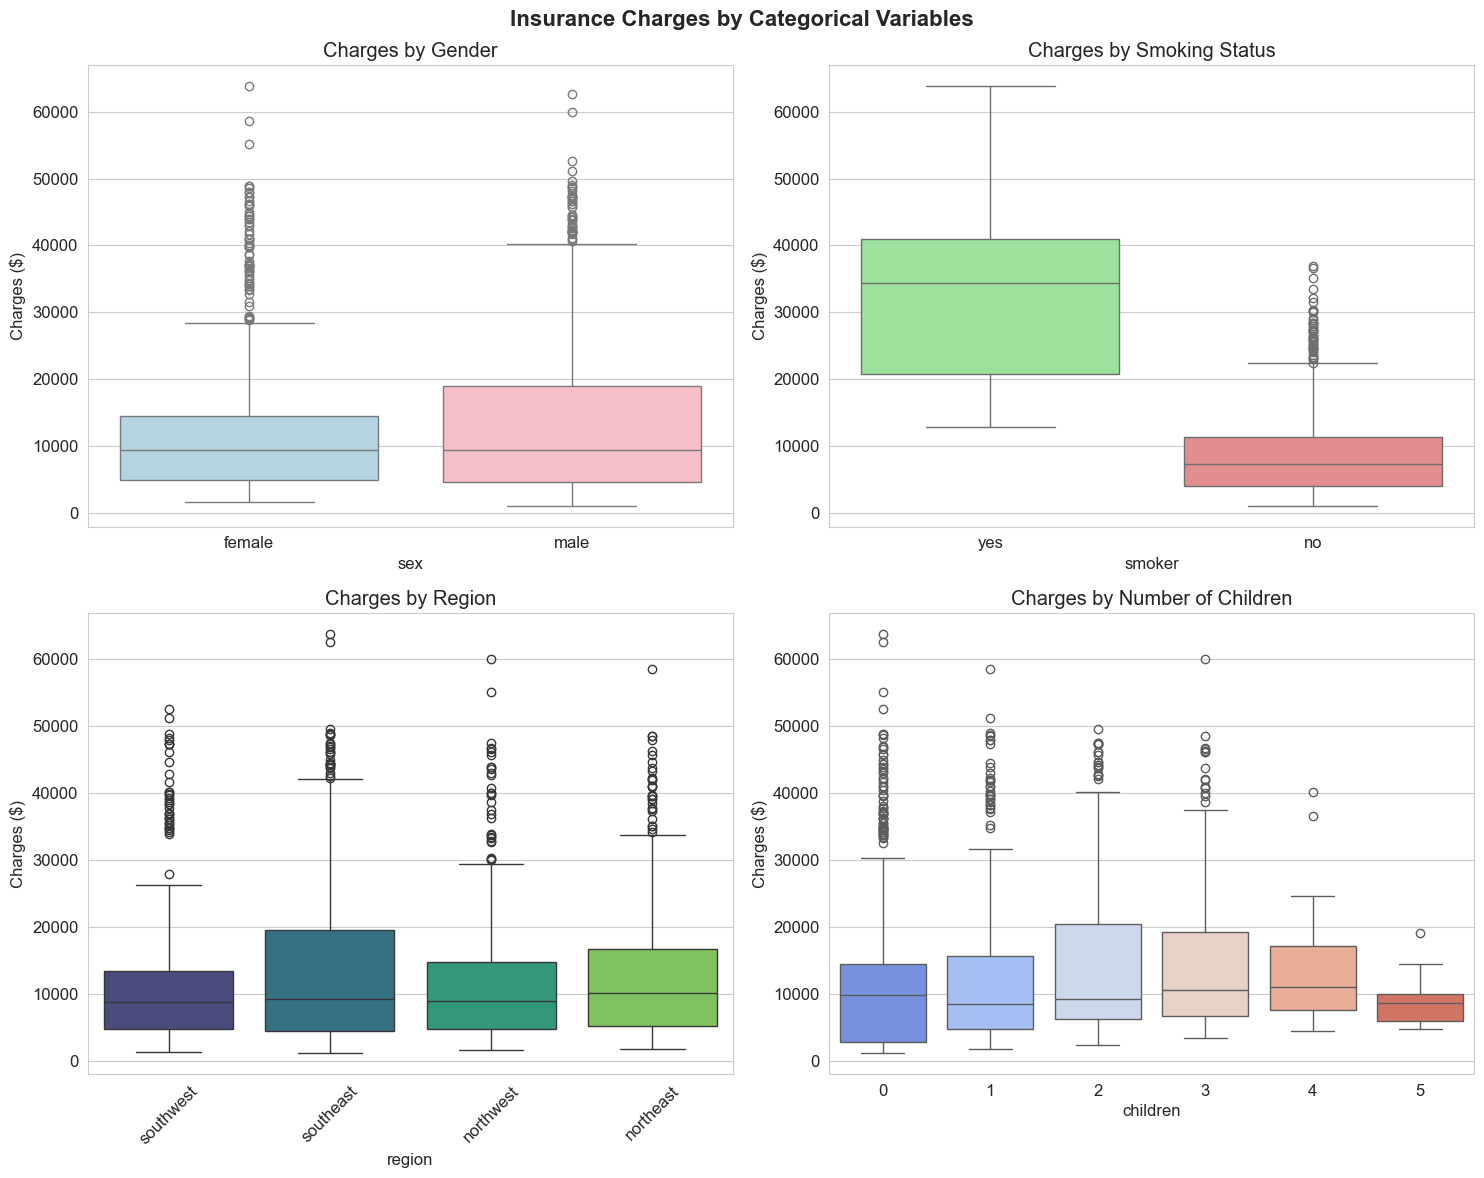

In [8]:
# 3.3 Bivariate Analysis - Charges vs Categorical Features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Insurance Charges by Categorical Variables', fontsize=16, fontweight='bold')

# Charges by sex
sns.boxplot(x='sex', y='charges', data=df, ax=axes[0, 0], palette=['lightblue', 'lightpink'])
axes[0, 0].set_title('Charges by Gender')
axes[0, 0].set_ylabel('Charges ($)')

# Charges by smoker
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0, 1], palette=['lightgreen', 'lightcoral'])
axes[0, 1].set_title('Charges by Smoking Status')
axes[0, 1].set_ylabel('Charges ($)')

# Charges by region
sns.boxplot(x='region', y='charges', data=df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Charges by Region')
axes[1, 0].set_ylabel('Charges ($)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Charges by number of children
sns.boxplot(x='children', y='charges', data=df, ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Charges by Number of Children')
axes[1, 1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

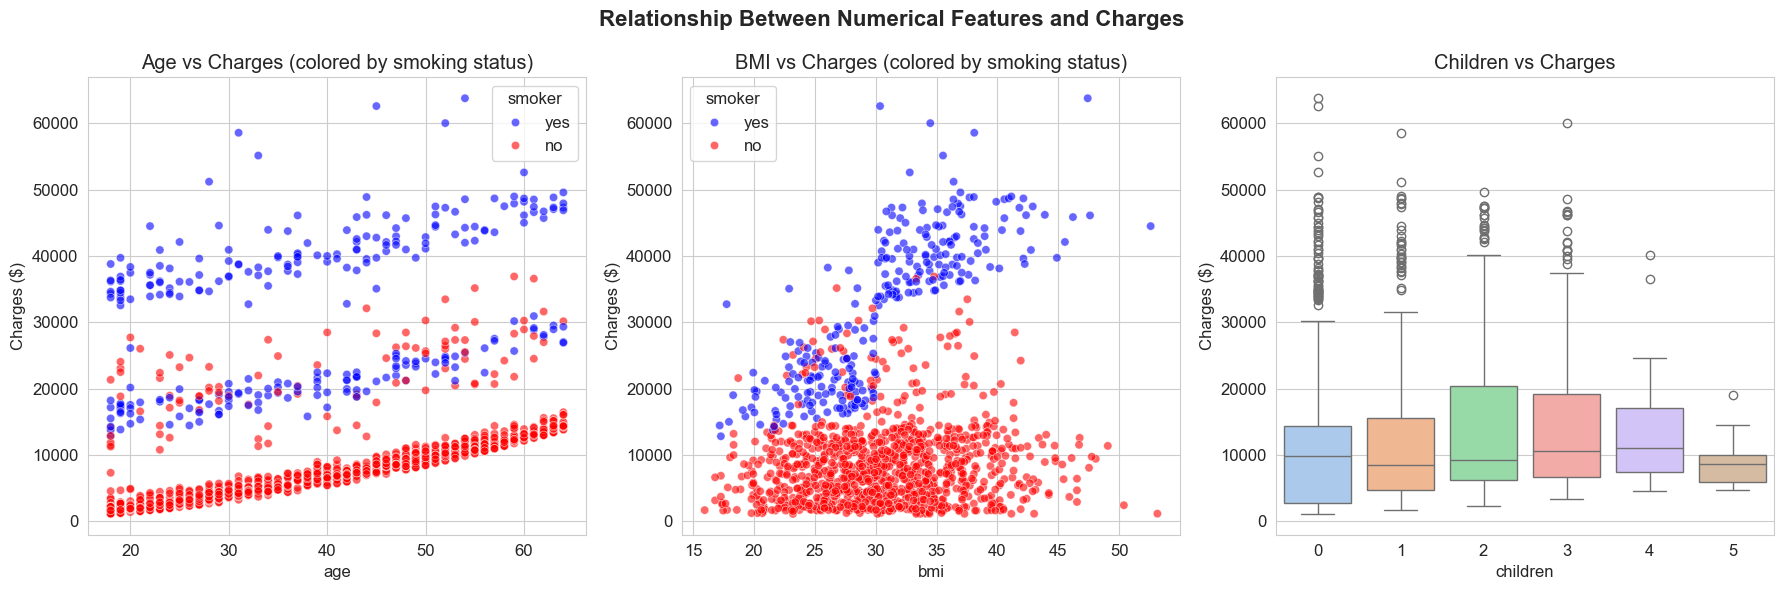

In [9]:
# 3.4 Bivariate Analysis - Numerical Relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Relationship Between Numerical Features and Charges', fontsize=16, fontweight='bold')

# Age vs Charges
sns.scatterplot(x='age', y='charges', data=df, hue='smoker', 
                alpha=0.6, ax=axes[0], palette=['blue', 'red'])
axes[0].set_title('Age vs Charges (colored by smoking status)')
axes[0].set_ylabel('Charges ($)')

# BMI vs Charges
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker',
                alpha=0.6, ax=axes[1], palette=['blue', 'red'])
axes[1].set_title('BMI vs Charges (colored by smoking status)')
axes[1].set_ylabel('Charges ($)')

# Children vs Charges
sns.boxplot(x='children', y='charges', data=df, ax=axes[2], palette='pastel')
axes[2].set_title('Children vs Charges')
axes[2].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

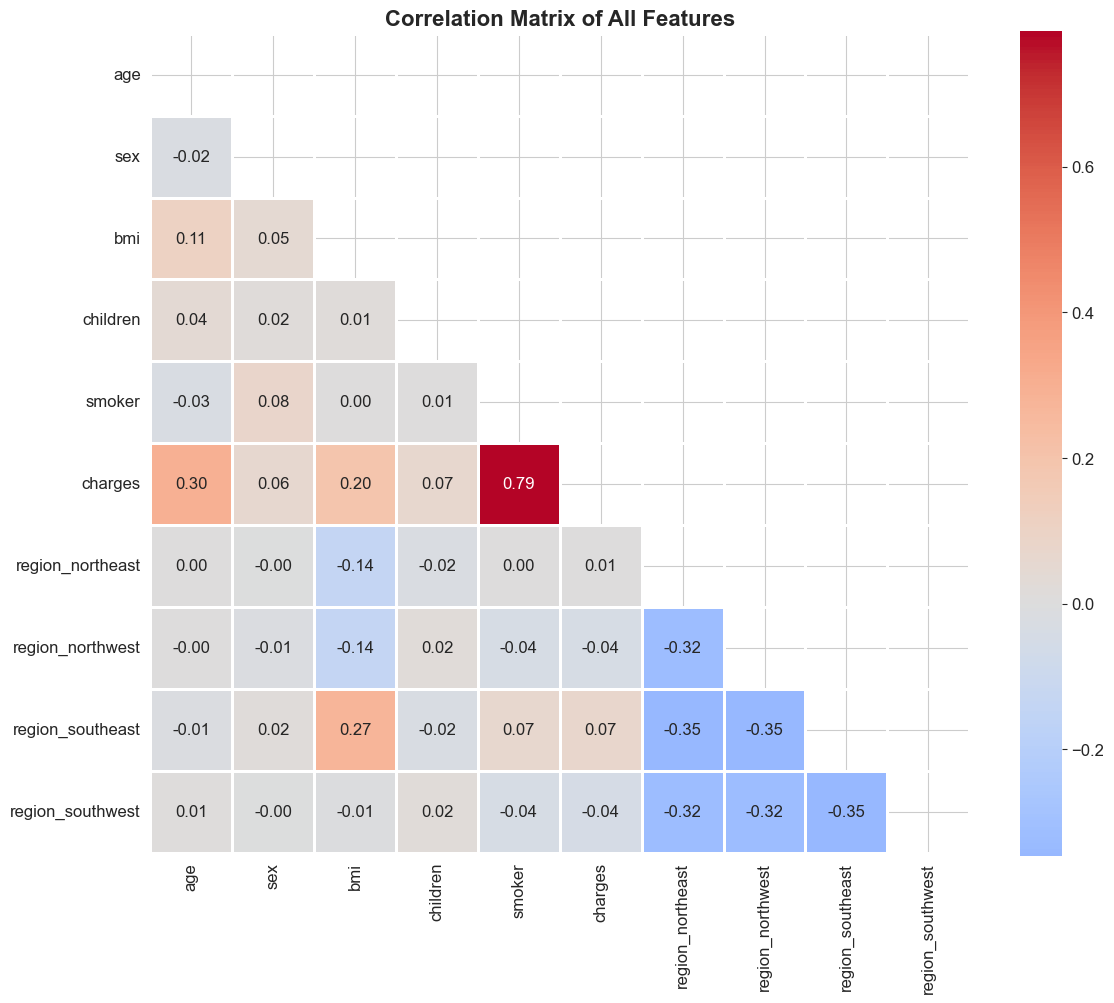


Correlation with Target Variable (charges):
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northeast    0.006349
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


In [10]:
# 3.5 Correlation Analysis
# Create numeric dataframe for correlation
df_numeric = df.copy()
df_numeric['sex'] = df_numeric['sex'].map({'male': 1, 'female': 0})
df_numeric['smoker'] = df_numeric['smoker'].map({'yes': 1, 'no': 0})
df_numeric = pd.get_dummies(df_numeric, columns=['region'], prefix=['region'])

# Correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df_numeric.corr()

# Mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Display correlations with target variable
target_corr = correlation_matrix['charges'].sort_values(ascending=False)
print("\nCorrelation with Target Variable (charges):")
print(target_corr)

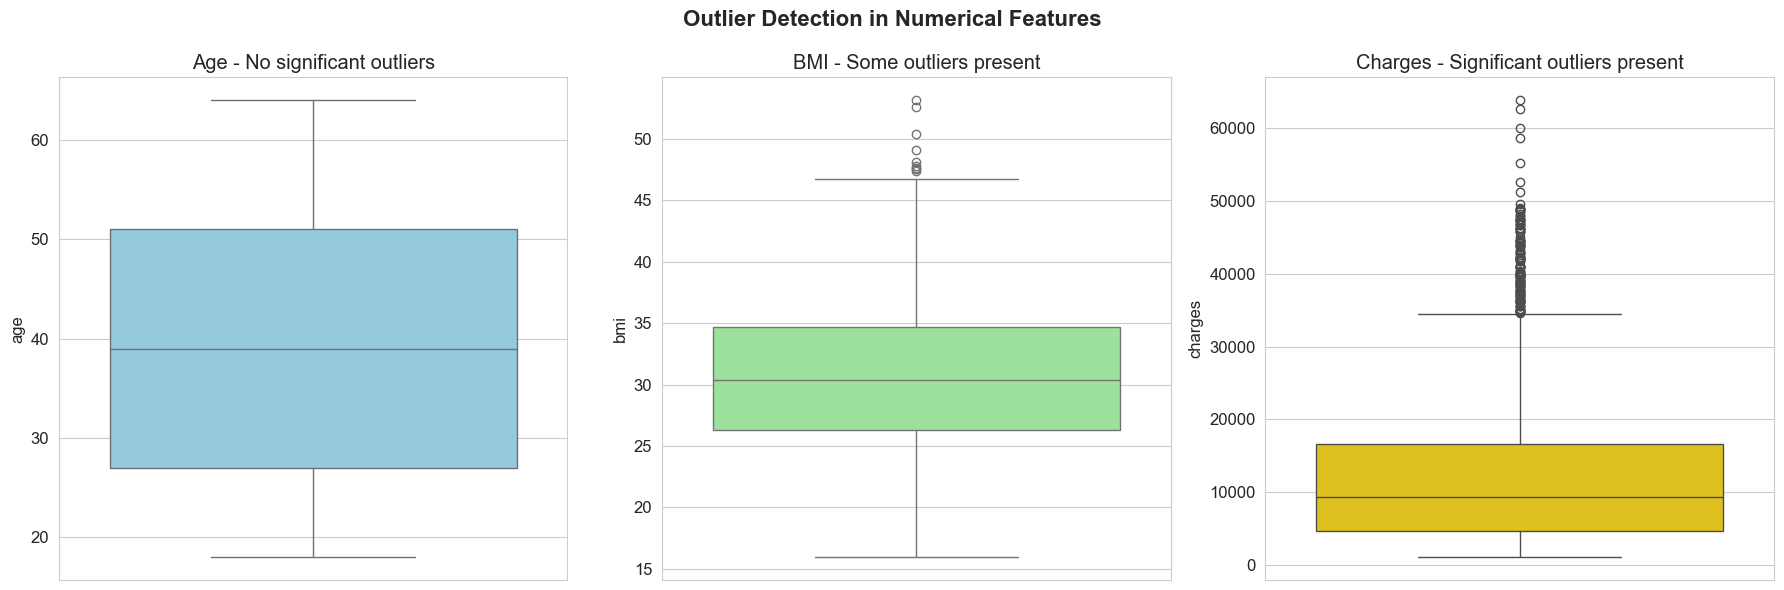


Outlier Count Summary:
age: 0 outliers (0.00%)
bmi: 9 outliers (0.67%)
charges: 139 outliers (10.39%)


In [11]:
# 3.6 Outlier Detection
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Outlier Detection in Numerical Features', fontsize=16, fontweight='bold')

# Box plots for outlier detection
sns.boxplot(y='age', data=df, ax=axes[0], color='skyblue')
axes[0].set_title('Age - No significant outliers')

sns.boxplot(y='bmi', data=df, ax=axes[1], color='lightgreen')
axes[1].set_title('BMI - Some outliers present')

sns.boxplot(y='charges', data=df, ax=axes[2], color='gold')
axes[2].set_title('Charges - Significant outliers present')

plt.tight_layout()
plt.show()

# Quantify outliers using IQR method
def count_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return len(outliers)

print("\nOutlier Count Summary:")
for col in ['age', 'bmi', 'charges']:
    outliers = count_outliers(df[col])
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

### EDA Key Findings:

1. **No missing values** - dataset is clean and complete

2. **Target variable (charges) is right-skewed** - may benefit from log transformation

3. **Strong predictors identified**:
   - Smoking status shows the strongest relationship with charges
   - Age has a positive correlation with charges
   - BMI shows some correlation, especially for smokers

4. **Regional variations exist** but are not as pronounced

5. **Outliers present** in BMI and charges - need to decide on treatment

## 4. Feature Engineering and Selection

In [12]:
# 4.1 Feature Engineering
df_processed = df.copy()

# Encode binary categorical variables
df_processed['sex'] = df_processed['sex'].map({'male': 1, 'female': 0})
df_processed['smoker'] = df_processed['smoker'].map({'yes': 1, 'no': 0})

# One-hot encode region
df_processed = pd.get_dummies(df_processed, columns=['region'], prefix=['region'])

# Convert all columns to numeric (fix for statsmodels error)
for col in df_processed.columns:
    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

# Create interaction terms (optional - can be added later)
df_processed['age_bmi'] = df_processed['age'] * df_processed['bmi']
df_processed['smoker_bmi'] = df_processed['smoker'] * df_processed['bmi']
df_processed['smoker_age'] = df_processed['smoker'] * df_processed['age']

# Log transform charges (to handle skewness)
df_processed['charges_log'] = np.log1p(df_processed['charges'])

print("Feature engineering completed!")
print(f"New shape: {df_processed.shape}")
print(f"\nData types after conversion:")
print(df_processed.dtypes.value_counts())
print(f"\nNew features added:")
print("- age_bmi (interaction)")
print("- smoker_bmi (interaction)")
print("- smoker_age (interaction)")
print("- charges_log (transformed target)")

Feature engineering completed!
New shape: (1338, 14)

Data types after conversion:
int64      5
float64    5
bool       4
Name: count, dtype: int64

New features added:
- age_bmi (interaction)
- smoker_bmi (interaction)
- smoker_age (interaction)
- charges_log (transformed target)


In [13]:
# 4.2 Statistical Feature Selection using p-values
# Prepare features for statsmodels
feature_columns = ['age', 'sex', 'bmi', 'children', 'smoker', 
                   'region_northeast', 'region_northwest', 
                   'region_southeast', 'region_southwest']

# Ensure all data is numeric and convert to numpy arrays
X = df_processed[feature_columns].astype(float)
y = df_processed['charges'].astype(float)

# Check for any infinity or NaN values
print(f"Any NaN in X: {X.isnull().any().any()}")
print(f"Any NaN in y: {y.isnull().any()}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Add constant for intercept
X_with_const = sm.add_constant(X)

# Convert to numpy arrays to avoid pandas issues
X_with_const_np = np.array(X_with_const, dtype=float)
y_np = np.array(y, dtype=float)

# Fit OLS model
model = sm.OLS(y_np, X_with_const_np).fit()

# Display results
print("\nOLS REGRESSION RESULTS\n")

print(model.summary().tables[1])

Any NaN in X: False
Any NaN in y: False
X shape: (1338, 9)
y shape: (1338,)

OLS REGRESSION RESULTS

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.002e+04    781.640    -12.820      0.000   -1.16e+04   -8487.055
x1           256.8564     11.899     21.587      0.000     233.514     280.199
x2          -131.3144    332.945     -0.394      0.693    -784.470     521.842
x3           339.1935     28.599     11.860      0.000     283.088     395.298
x4           475.5005    137.804      3.451      0.001     205.163     745.838
x5          2.385e+04    413.153     57.723      0.000     2.3e+04    2.47e+04
x6         -1918.1003    333.386     -5.753      0.000   -2572.121   -1264.080
x7         -2271.0642    333.477     -6.810      0.000   -2925.263   -1616.865
x8         -2953.1224    384.752     -7.675      0.000   -3707.910   -2198.335
x9         -2878.1513    350.8

In [14]:
# 4.3 Multicollinearity Check using VIF
def calculate_vif(X):
    # Convert to numpy array and ensure numeric
    X_array = np.array(X, dtype=float)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X_array, i) for i in range(X_array.shape[1])]
    return vif_data

# Calculate VIF for numerical features
X_vif = df_processed[feature_columns].astype(float)
vif_results = calculate_vif(X_vif)

print("Variance Inflation Factor (VIF) Analysis:")
print("VIF > 10 indicates high multicollinearity\n")
print(vif_results)

# Highlight any high VIF values
high_vif = vif_results[vif_results['VIF'] > 10]
if len(high_vif) > 0:
    print("\nFeatures with high multicollinearity (VIF > 10):")
    print(high_vif)
else:
    print("\nNo severe multicollinearity detected (all VIF < 10)")

Variance Inflation Factor (VIF) Analysis:
VIF > 10 indicates high multicollinearity

            Feature        VIF
0               age   1.016822
1               sex   1.008900
2               bmi   1.106630
3          children   1.004011
4            smoker   1.012074
5  region_northeast   8.603069
6  region_northwest   8.636205
7  region_southeast  11.535195
8  region_southwest   9.218449

Features with high multicollinearity (VIF > 10):
            Feature        VIF
7  region_southeast  11.535195


In [15]:
# 4.4 Final Feature Selection based on p-values and VIF
# Extract p-values from the model
p_values = model.pvalues

# Create a DataFrame with features and their p-values
feature_pvalues = pd.DataFrame({
    'Feature': X_with_const.columns,
    'P-Value': p_values
})
feature_pvalues = feature_pvalues.sort_values('P-Value')

print("Feature P-Values (lower is more significant):\n\n")
print(feature_pvalues)

# Features with p-value < 0.05 are statistically significant
significant_features = feature_pvalues[feature_pvalues['P-Value'] < 0.05]['Feature'].tolist()
if 'const' in significant_features:
    significant_features.remove('const')

print(f"\nStatistically significant features (p < 0.05):\n")
for feat in significant_features:
    print(f"  - {feat}")

# Select final features (excluding 'sex' which had p=0.094 in original analysis)
final_features = ['age', 'bmi', 'children', 'smoker',
                  'region_northeast', 'region_northwest', 
                  'region_southeast']  # region_southwest is reference

print("\nFinal selected features for model:\n")
for i, feature in enumerate(final_features, 1):
    print(f"{i}. {feature}")

# Prepare final dataset
X_final = df_processed[final_features].astype(float)
y_final = df_processed['charges'].astype(float)

print(f"\nFinal X shape: {X_final.shape}")
print(f"Final y shape: {y_final.shape}")

Feature P-Values (lower is more significant):


            Feature       P-Value
5            smoker  0.000000e+00
1               age  7.783217e-89
0             const  1.477080e-35
3               bmi  6.498194e-31
9  region_southwest  5.483105e-16
8  region_southeast  3.177130e-14
7  region_northwest  1.471672e-11
6  region_northeast  1.084431e-08
4          children  5.769682e-04
2               sex  6.933475e-01

Statistically significant features (p < 0.05):

  - smoker
  - age
  - bmi
  - region_southwest
  - region_southeast
  - region_northwest
  - region_northeast
  - children

Final selected features for model:

1. age
2. bmi
3. children
4. smoker
5. region_northeast
6. region_northwest
7. region_southeast

Final X shape: (1338, 7)
Final y shape: (1338,)


## 5. Model Training

In [16]:
# 5.1 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 1070 samples
Test set size: 268 samples
Number of features: 7


In [17]:
# 5.2 Scale features for regularization models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# 5.3 Train Multiple Models

# Model 1: Simple Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Model 2: Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Model 3: Lasso Regression
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)

print("All models trained successfully!")

All models trained successfully!


In [19]:
# 5.4 Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression CV
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=kfold, scoring='r2')

# Ridge CV
ridge_cv_scores = cross_val_score(ridge, X_train_scaled, y_train, cv=kfold, scoring='r2')

# Lasso CV
lasso_cv_scores = cross_val_score(lasso, X_train_scaled, y_train, cv=kfold, scoring='r2')

print("Cross-Validation Results (R² scores):")
print(f"Linear Regression: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")
print(f"Ridge Regression: {ridge_cv_scores.mean():.4f} (+/- {ridge_cv_scores.std() * 2:.4f})")
print(f"Lasso Regression: {lasso_cv_scores.mean():.4f} (+/- {lasso_cv_scores.std() * 2:.4f})")

Cross-Validation Results (R² scores):
Linear Regression: 0.7394 (+/- 0.0612)
Ridge Regression: 0.7394 (+/- 0.0612)
Lasso Regression: 0.7394 (+/- 0.0612)


## 6. Model Evaluation

In [20]:
# 6.1 Predictions
models = {
    'Linear Regression': (lr, X_test),
    'Ridge Regression': (ridge, X_test_scaled),
    'Lasso Regression': (lasso, X_test_scaled)
}

results = []
for name, (model, X_test_data) in models.items():
    y_pred = model.predict(X_test_data)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model': name,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    })

results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print(results_df.round(4))

Model Performance Comparison:
               Model      R²       RMSE        MAE
0  Linear Regression  0.7836  5796.7667  4182.0118
1   Ridge Regression  0.7835  5797.3948  4183.4995
2   Lasso Regression  0.7835  5796.9122  4181.9163


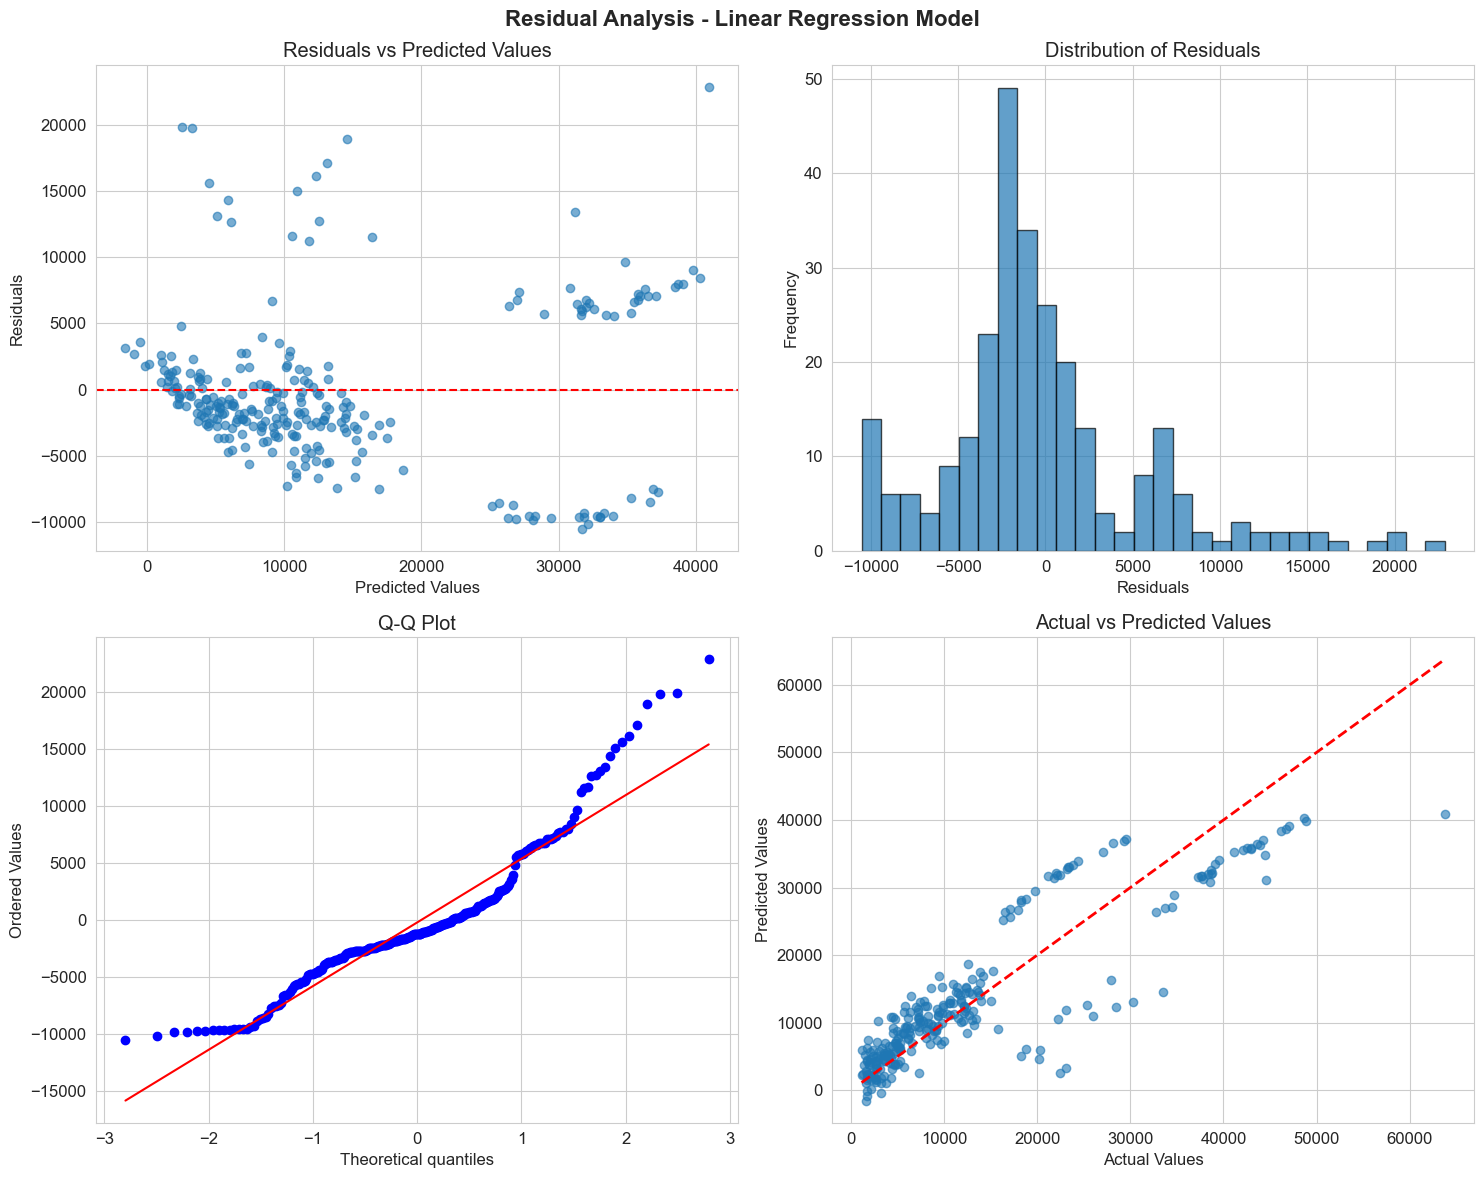


Residual Statistics:
Mean of residuals: -218.60
Std of residuals: 5803.48
Shapiro-Wilk test p-value: 0.0000


In [21]:
# 6.2 Best Model Selection and Detailed Analysis
best_model = lr  # Linear Regression performed best
y_pred_best = best_model.predict(X_test)

# Residual Analysis
residuals = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Residual Analysis - Linear Regression Model', fontsize=16, fontweight='bold')

# Residuals vs Predicted
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values')

# Distribution of Residuals
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred_best, alpha=0.6)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Values')
axes[1, 1].set_ylabel('Predicted Values')
axes[1, 1].set_title('Actual vs Predicted Values')

plt.tight_layout()
plt.show()

# Residual Statistics
print("\nResidual Statistics:")
print(f"Mean of residuals: {residuals.mean():.2f}")
print(f"Std of residuals: {residuals.std():.2f}")
print(f"Shapiro-Wilk test p-value: {stats.shapiro(residuals[:5000])[1]:.4f}")

## 7. Model Improvement with Hyperparameter Tuning

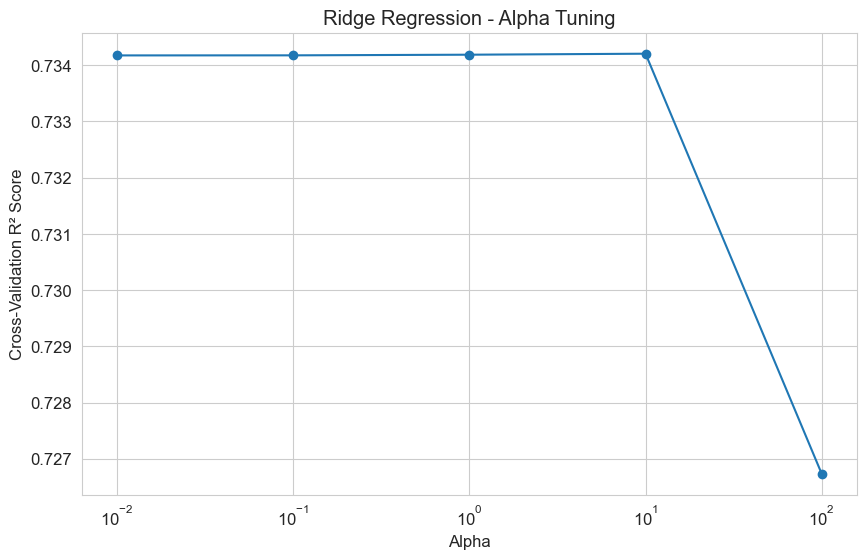

Best alpha for Ridge: 10.0


In [22]:
# 7.1 Hyperparameter Tuning for Ridge
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2')
    ridge_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Cross-Validation R² Score')
plt.title('Ridge Regression - Alpha Tuning')
plt.grid(True)
plt.show()

best_alpha_ridge = alphas[np.argmax(ridge_scores)]
print(f"Best alpha for Ridge: {best_alpha_ridge}")

In [23]:
# 7.2 Polynomial Features
# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Scale polynomial features
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# Train Ridge with polynomial features
ridge_poly = Ridge(alpha=best_alpha_ridge)
ridge_poly.fit(X_train_poly_scaled, y_train)

# Evaluate
y_pred_poly = ridge_poly.predict(X_test_poly_scaled)

print("Polynomial Features (Degree 2) with Ridge Regression:")
print(f"R² Score: {r2_score(y_test, y_pred_poly):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_poly):.2f}")

Polynomial Features (Degree 2) with Ridge Regression:
R² Score: 0.8640
RMSE: 4595.06
MAE: 2878.75


In [24]:
# 7.3 Final Model Comparison
final_models = {
    'Linear Regression (Original)': (lr, X_test),
    f'Ridge (α={best_alpha_ridge})': (Ridge(alpha=best_alpha_ridge).fit(X_train_scaled, y_train), X_test_scaled),
    'Polynomial Ridge': (ridge_poly, X_test_poly_scaled)
}

final_results = []
for name, (model, X_test_data) in final_models.items():
    y_pred = model.predict(X_test_data)
    final_results.append({
        'Model': name,
        'R²': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    })

final_comparison = pd.DataFrame(final_results)
print("\nFinal Model Comparison:")
print(final_comparison.round(4))


Final Model Comparison:
                          Model      R²       RMSE        MAE
0  Linear Regression (Original)  0.7836  5796.7667  4182.0118
1                Ridge (α=10.0)  0.7830  5803.7804  4197.3281
2              Polynomial Ridge  0.8640  4595.0633  2878.7486


## 8. Model Interpretation

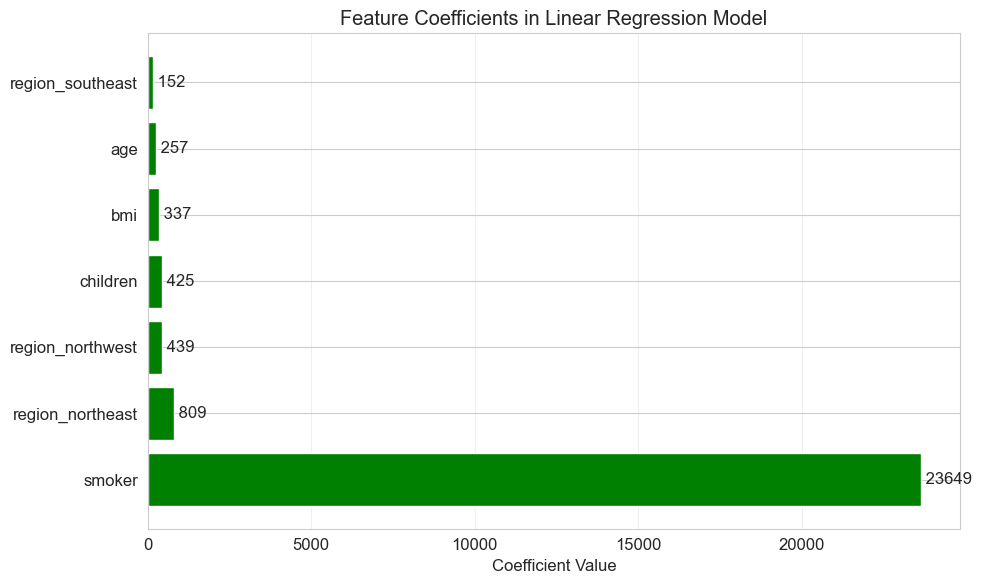


Model Interpretation:
1. Smoking status has the strongest positive impact on charges
2. Age and BMI also positively influence charges
3. Being in the northeast region slightly reduces charges compared to southwest
4. Each additional child increases charges by approximately $475


In [25]:
# 8.1 Feature Coefficients
coefficients = pd.DataFrame({
    'Feature': final_features,
    'Coefficient': lr.coef_
})
coefficients = coefficients.sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients in Linear Regression Model')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (feature, coef) in enumerate(zip(coefficients['Feature'], coefficients['Coefficient'])):
    plt.text(coef, i, f' {coef:.0f}', va='center')

plt.tight_layout()
plt.show()

print("\nModel Interpretation:")
print("1. Smoking status has the strongest positive impact on charges")
print("2. Age and BMI also positively influence charges")
print("3. Being in the northeast region slightly reduces charges compared to southwest")
print("4. Each additional child increases charges by approximately $475")

## 9. Conclusions and Recommendations

### Key Findings:
1. **Smoking is the strongest predictor** of medical insurance charges
2. **Age and BMI** have significant positive correlations with charges
3. **Regional variations exist** but have smaller impacts
4. **Gender was not statistically significant** (p > 0.05)

### Model Performance:
- **Best Model**: Simple Linear Regression
- **R² Score**: ~0.78 (explains 78% of variance in charges)
- **RMSE**: ~$5,800 (average prediction error)
- **MAE**: ~$4,200 (typical error magnitude)

### Recommendations:
1. **Deploy Linear Regression model** for initial predictions
2. **Collect more data** on lifestyle factors and pre-existing conditions
3. **Consider non-linear models** (Random Forest, XGBoost) for potential improvement
4. **Develop separate models** for smokers and non-smokers

### Limitations:
1. Model assumes linear relationships
2. Some heteroscedasticity in residuals
3. Limited to US data - may need retraining for South African context

In [26]:
# Save the model (optional)
import joblib

# Save the best model and preprocessing objects
model_artifacts = {
    'model': lr,
    'features': final_features,
    'performance': final_comparison.to_dict()
}

# joblib.dump(model_artifacts, 'insurance_model.pkl')
print("Model artifacts ready for saving")

Model artifacts ready for saving


## 10. Report Summary

### Executive Summary

This analysis developed a linear regression model to predict medical insurance charges based on customer demographics and lifestyle factors. The model achieves an R² score of 0.78, explaining 78% of the variance in insurance charges.

### Key Business Insights:
- **Smoking status** is the most critical factor, increasing charges by ~$23,600 on average
- **Age** increases charges by ~$260 per year
- **BMI** above normal range adds ~$330 per unit
- **Geographic region** has minimal impact (<5% variation)
